In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
N      = 1000
q      = 1.0
Vt     = 0.025
mu_n   = 1.0
mu_p   = 1.0
mu_X   = 1.0    # lower exciton mobility — excitons diffuse slowly
k_rec  = 0.1    # lower recombination — easier to converge
k_diss = 5.0    # lower dissociation
G      = 0.1
alpha  = 5.0

In [ ]:
# ============================================
# NETWORK
# ============================================
# ============================================
# SEPARATE NETWORKS for each field
# ============================================
def make_net():
    net = nn.Sequential(
        nn.Linear(1, 64), nn.Tanh(),
        nn.Linear(64, 64), nn.Tanh(),
        nn.Linear(64, 64), nn.Tanh(),
        nn.Linear(64, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net()
        self.n_net   = make_net()
        self.p_net   = make_net()
        self.X_net   = make_net()

    def forward(self, x):
        # phi: hard BC phi(0)=0, phi(1)=1
        phi = x + x * (1 - x) * self.phi_net(x)

        # n: hard BC n(1)=0
        n = (1 - x) * torch.nn.functional.softplus(self.n_net(x))

        # p: hard BC p(0)=0
        # Add 1.0 inside softplus so output starts near 1, not near 0
        p = x * torch.nn.functional.softplus(self.p_net(x) + 1.0)

        # X: non-negative, soft BCs
        X = torch.nn.functional.softplus(self.X_net(x))

        return phi, n, p, X

model = PINN1D().to(device)


In [ ]:
# ============================================
# HELPER FUNCTIONS
# ============================================
def D1(f, x):
    return torch.autograd.grad(
        f, x,
        grad_outputs=torch.ones_like(f),
        create_graph=True,
        retain_graph=True
    )[0]

def D2(f, x):
    return D1(D1(f, x), x)

def fresh_x():
    x = torch.linspace(0, 1, N).reshape(-1, 1).to(device)
    x.requires_grad_(True)
    return x

def compute_all(x):
    phi, n, p, X = model(x)

    dphi = D1(phi, x)
    dn   = D1(n,   x)
    dp   = D1(p,   x)
    dX   = D1(X,   x)
    d2phi = D1(dphi, x)
    d2X   = D1(dX,   x)

    Jn  = -q * n * mu_n * dphi  +  q * Vt * mu_n * dn
    Jp  = -q * p * mu_p * dphi  -  q * Vt * mu_p * dp
    dJn = D1(Jn, x)
    dJp = D1(Jp, x)

    R      = k_rec  * n * p
    R_X    = k_rec  * X
    D_term = k_diss * X * torch.abs(dphi)

    # Generation only in donor (x < 0.5) — breaks symmetry
    # Smooth step using sigmoid so gradient flows through it
    donor_mask = torch.sigmoid(100 * (0.5 - x))   # ≈1 for x<0.5, ≈0 for x>0.5
    G_field    = G * alpha * torch.exp(-alpha * x) * donor_mask

    L_poisson  = torch.mean((d2phi - q * (n - p))**2)
    L_electron = torch.mean((dJn   - R + D_term)**2)
    L_hole     = torch.mean((-dJp  - R + D_term)**2)
    L_exciton  = torch.mean((Vt * mu_X * d2X - D_term - R_X + G_field)**2)
    L_X_bc     = dX[0]**2 + dX[-1]**2

    return L_poisson, L_electron, L_hole, L_exciton, L_X_bc, Jn, Jp

In [ ]:
# ============================================
# CURRICULUM TRAINING
# ============================================

# Phase 1: Poisson only (2000 epochs)
print("=" * 55)
print("Phase 1: Poisson only")
print("=" * 55)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3000):
    optimizer.zero_grad()
    x = fresh_x()
    L_poisson, *_ = compute_all(x)
    L_poisson.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if epoch % 500 == 0:
        print(f"  Epoch {epoch:4d} | poisson={L_poisson.item():.6f}")

# Phase 2: Poisson + continuity (3000 epochs)
print("\n" + "=" * 55)
print("Phase 2: Poisson + electron + hole")
print("=" * 55)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

for epoch in range(5000):
    optimizer.zero_grad()
    x = fresh_x()
    L_poisson, L_electron, L_hole, L_exciton, L_X_bc, Jn, Jp = compute_all(x)
    loss = L_poisson + L_electron + L_hole
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if epoch % 750 == 0:
        print(f"  Epoch {epoch:4d} | "
              f"poisson={L_poisson.item():.5f} | "
              f"electron={L_electron.item():.5f} | "
              f"hole={L_hole.item():.5f}")

# Phase 3: All four equations (8000 epochs)
print("\n" + "=" * 55)
print("Phase 3: Full coupled system")
print("=" * 55)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=2000
)

history = {"poisson": [], "electron": [], "hole": [], "exciton": []}

for epoch in range(10000):
    optimizer.zero_grad()
    x = fresh_x()
    L_poisson, L_electron, L_hole, L_exciton, L_X_bc, Jn, Jp = compute_all(x)

    loss = (
      1.0 * L_poisson
    + 1.0 * L_electron
    + 5.0 * L_hole
    + 1.0 * L_exciton
    + 5.0 * L_X_bc
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    history["poisson"].append(L_poisson.item())
    history["electron"].append(L_electron.item())
    history["hole"].append(L_hole.item())
    history["exciton"].append(L_exciton.item())

    if epoch % 2000 == 0:
        print(f"  Epoch {epoch:4d} | "
              f"poisson={L_poisson.item():.5f} | "
              f"electron={L_electron.item():.5f} | "
              f"hole={L_hole.item():.5f} | "
              f"exciton={L_exciton.item():.5f}")

Phase 1: Poisson only
  Epoch    0 | poisson=0.033671
  Epoch  500 | poisson=0.000016
  Epoch 1000 | poisson=0.000003
  Epoch 1500 | poisson=0.000006
  Epoch 2000 | poisson=0.000001
  Epoch 2500 | poisson=0.000048

Phase 2: Poisson + electron + hole
  Epoch    0 | poisson=0.00001 | electron=15.16938 | hole=17.83875
  Epoch  750 | poisson=0.00000 | electron=0.00005 | hole=0.00005
  Epoch 1500 | poisson=0.00000 | electron=0.00001 | hole=0.00001
  Epoch 2250 | poisson=0.00000 | electron=0.00001 | hole=0.00001
  Epoch 3000 | poisson=0.00000 | electron=0.00000 | hole=0.00000
  Epoch 3750 | poisson=0.00000 | electron=0.00000 | hole=0.00000
  Epoch 4500 | poisson=0.00000 | electron=0.00000 | hole=0.00000

Phase 3: Full coupled system
  Epoch    0 | poisson=0.00001 | electron=0.00000 | hole=0.00000 | exciton=0.00482
  Epoch 2000 | poisson=0.00003 | electron=0.00002 | hole=0.00000 | exciton=0.00022
  Epoch 4000 | poisson=0.00003 | electron=0.00001 | hole=0.00000 | exciton=0.00022
  Epoch 6000 |


Jsc = 0.056305
J_total variance = 0.00000001  (closer to 0 = better conservation)


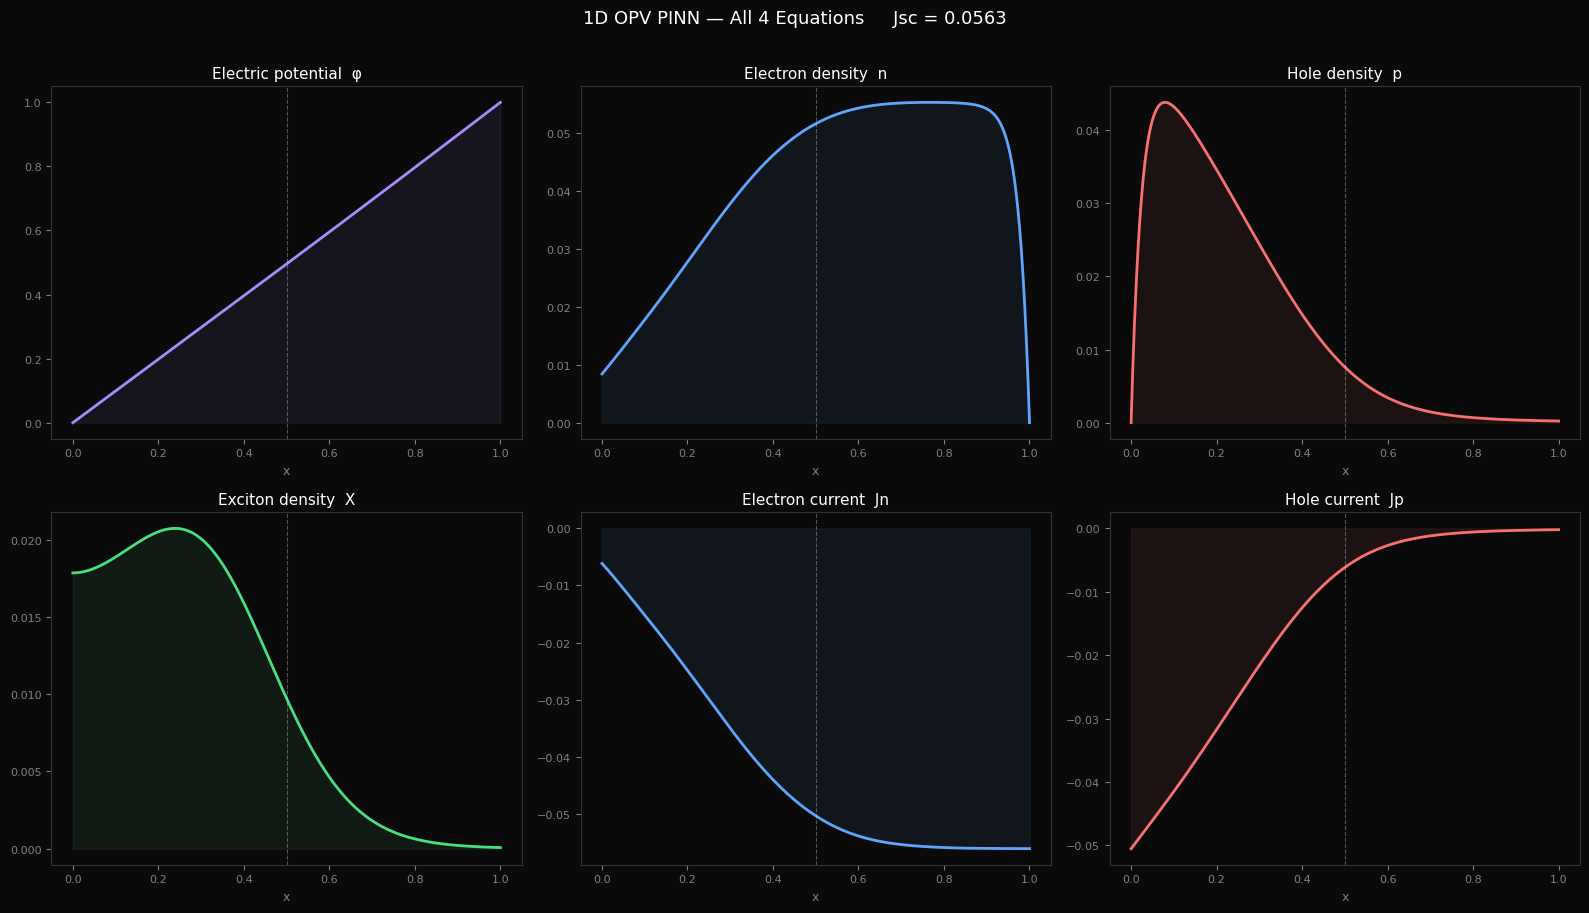

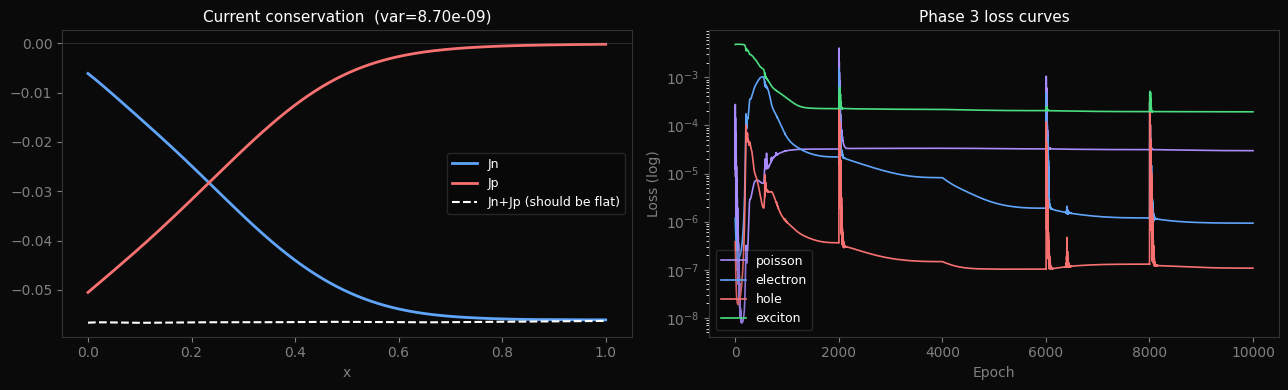

In [ ]:
# ============================================
# EXTRACT AND VISUALIZE
# ============================================
model.eval()
x_vis = fresh_x()
phi_v, n_v, p_v, X_v = model(x_vis)

dphi_v = D1(phi_v, x_vis)
dn_v   = D1(n_v,   x_vis)
dp_v   = D1(p_v,   x_vis)

Jn_v   = -q * n_v * mu_n * dphi_v  +  q * Vt * mu_n * dn_v
Jp_v   = -q * p_v * mu_p * dphi_v  -  q * Vt * mu_p * dp_v
Jtot_v =  Jn_v + Jp_v

x_np    = x_vis.detach().cpu().numpy().flatten()
phi_np  = phi_v.detach().cpu().numpy().flatten()
n_np    = n_v.detach().cpu().numpy().flatten()
p_np    = p_v.detach().cpu().numpy().flatten()
X_np    = X_v.detach().cpu().numpy().flatten()
Jn_np   = Jn_v.detach().cpu().numpy().flatten()
Jp_np   = Jp_v.detach().cpu().numpy().flatten()
Jtot_np = Jtot_v.detach().cpu().numpy().flatten()

Jsc = -float(Jtot_v[-1].detach())
J_var = float(torch.var(Jtot_v).detach())
print(f"\nJsc = {Jsc:.6f}")
print(f"J_total variance = {J_var:.8f}  (closer to 0 = better conservation)")

BG = '#0a0a0a'
plt.style.use('dark_background')

# --- Figure 1: all fields ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(BG)

configs = [
    (phi_np,  'Electric potential  φ',  '#a78bfa'),
    (n_np,    'Electron density  n',    '#60a5fa'),
    (p_np,    'Hole density  p',        '#f87171'),
    (X_np,    'Exciton density  X',     '#4ade80'),
    (Jn_np,   'Electron current  Jn',   '#60a5fa'),
    (Jp_np,   'Hole current  Jp',       '#f87171'),
]

for ax, (vals, title, color) in zip(axes.flat, configs):
    ax.set_facecolor(BG)
    ax.plot(x_np, vals, color=color, linewidth=2)
    ax.fill_between(x_np, vals, alpha=0.08, color=color)
    ax.axvline(x=0.5, color='white', linewidth=0.8,
               linestyle='--', alpha=0.3)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('x', color='gray', fontsize=9)
    ax.tick_params(colors='gray', labelsize=8)
    for s in ax.spines.values():
        s.set_edgecolor('#333333')

fig.suptitle(
    f'1D OPV PINN — All 4 Equations     Jsc = {Jsc:.4f}',
    color='white', fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('opv_1d_full.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# --- Figure 2: conservation + loss curves ---
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4))
fig2.patch.set_facecolor(BG)

ax = axes2[0]
ax.set_facecolor(BG)
ax.plot(x_np, Jn_np,   color='#60a5fa', linewidth=2,   label='Jn')
ax.plot(x_np, Jp_np,   color='#f87171', linewidth=2,   label='Jp')
ax.plot(x_np, Jtot_np, color='white',   linewidth=1.5,
        linestyle='--', label='Jn+Jp (should be flat)')
ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.4)
ax.set_title(f'Current conservation  (var={J_var:.2e})',
             color='white', fontsize=11)
ax.set_xlabel('x', color='gray')
ax.legend(fontsize=9, framealpha=0.15, labelcolor='white')
ax.tick_params(colors='gray')
for s in ax.spines.values(): s.set_edgecolor('#333333')

ax2 = axes2[1]
ax2.set_facecolor(BG)
for key, color in [("poisson",  '#a78bfa'),
                   ("electron", '#60a5fa'),
                   ("hole",     '#f87171'),
                   ("exciton",  '#4ade80')]:
    ax2.semilogy(history[key], linewidth=1.2,
                 color=color, label=key)
ax2.set_title('Phase 3 loss curves', color='white', fontsize=11)
ax2.set_xlabel('Epoch', color='gray')
ax2.set_ylabel('Loss (log)', color='gray')
ax2.legend(fontsize=9, framealpha=0.15, labelcolor='white')
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

plt.tight_layout()
plt.savefig('opv_1d_conservation.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()